# Model-Consistent Sweep: Cross-Run Comparison

This notebook analyzes sweep summary CSV output and focuses on:

1. Which `lambda` values produce strong policies for **both** Shannon and Rao costs.
2. Where each cost is preferred under different noise regimes (`sigma_r`, `sigma_phi`).

Primary inputs are summary files from:

- `output/experiment2/sweep_model_consistent_streamlined_*/summary_*.csv`

You can point to one specific folder or aggregate multiple folders.

In [1]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, NullFormatter


def _latex_backend_available():
    has_latex = shutil.which('latex') is not None
    has_renderer = any(shutil.which(cmd) is not None for cmd in ('dvipng', 'dvisvgm', 'gs'))
    return has_latex and has_renderer


USE_TEX = _latex_backend_available()

sns.set_theme(style='whitegrid', context='paper')
plt.rcParams.update({
    'text.usetex': USE_TEX,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'Nimbus Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'figure.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.18,
    'grid.linewidth': 0.8,
    'grid.color': '#808080',
    'lines.linewidth': 2.2,
    'lines.markersize': 7,
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
if USE_TEX:
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}\usepackage{amssymb}'

POLICY_COLORS = {'Shannon': '#1f4e79', 'Rao': '#d17c22'}
POLICY_MARKERS = {'Shannon': 's', 'Rao': 'o'}
DELTA_CMAP = sns.diverging_palette(240, 15, s=90, l=45, as_cmap=True)
PREF_CMAP = sns.diverging_palette(220, 20, s=85, l=50, as_cmap=True)
FRACTION_CMAP = sns.light_palette('#1f4e79', as_cmap=True)


def style_axes(ax):
    ax.grid(True, which='major', alpha=0.18)
    ax.grid(True, which='minor', alpha=0.08)
    ax.tick_params(length=0)
    sns.despine(ax=ax)



def set_log_lambda_axis(ax):
    ax.set_xscale('log')
    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlabel(r'Penalty weight $\lambda$')



def noise_axis_labels(ax):
    ax.set_xlabel(r'Bearing noise $\sigma_{\phi}$')
    ax.set_ylabel(r'Range noise $\sigma_{r}$')


pd.set_option('display.max_columns', 200)

PROJECT_ROOT = Path('/global/home/hpc5656/SLAM')

# Option A: specific run folder
RUN_DIR = PROJECT_ROOT / 'output/experiment2/sweep_model_consistent_streamlined_20260328_200253'

# Option B: aggregate all matching folders by setting RUN_DIR = None
USE_ALL_SWEEP_FOLDERS = False

In [2]:
from typing import List, Optional

def collect_summary_files(project_root: Path, run_dir: Optional[Path], use_all: bool) -> List[Path]:
    if use_all:
        pattern = 'output/experiment2/sweep_model_consistent_streamlined_*/summary_*.csv'
        files = sorted(project_root.glob(pattern))
    else:
        if run_dir is None:
            raise ValueError('RUN_DIR must be set when USE_ALL_SWEEP_FOLDERS=False')
        files = sorted(run_dir.glob('summary_*.csv'))
    return files


summary_files = collect_summary_files(PROJECT_ROOT, RUN_DIR, USE_ALL_SWEEP_FOLDERS)
if not summary_files:
    raise FileNotFoundError('No summary_*.csv files found for current settings.')

print(f'Found {len(summary_files)} summary file(s):')
for p in summary_files:
    print(' -', p)

frames = []
for p in summary_files:
    df_i = pd.read_csv(p)
    df_i['source_summary_file'] = p.name
    df_i['source_run_dir'] = p.parent.name
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)
print('\nShape:', df.shape)
df.head(3)

Found 1 summary file(s):
 - /global/home/hpc5656/SLAM/output/experiment2/sweep_model_consistent_streamlined_20260328_200253/summary_M6_n4_nmap4_lambda1-2000_sr0.5-1.25_sp0.3-0.7_trials1000_s3_9090-9092.csv

Shape: (120, 28)


,lambda,beta,action_n,obs_n,sigma_r,sigma_phi,kernel_report_mode,kernel_actions_analyzed,n_master_seeds,iter_shannon,iter_rao,policy_diff_rate,cost_rank_spearman,kernel_row_coverage_mean,kernel_bad_rows_total,final_gap_mean_sh_minus_ra_pooled,final_gap_ci95_pooled_trials,final_gap_mean_sh_minus_ra_across_seeds,final_gap_ci95_across_seeds,rao_win_rate_pooled,q95_terminal_mse_shannon,q95_terminal_mse_rao,cvar90_terminal_mse_shannon,cvar90_terminal_mse_rao,mean_cumul_effort_shannon,mean_cumul_effort_rao,source_summary_file,source_run_dir
0,1.0,0.95,8,5,0.5,0.3,none,0,3,238,238,0.087247,0.497363,NaN,-1,0.215261,0.108447,0.215261,0.076836,0.207000,28.125,28.125,35.825138,35.775136,18.842625,17.438104,summary_M6_n4_nmap4_lambda1-2000_sr0.5-1.25_sp...,sweep_model_consistent_streamlined_20260328_20...
1,2.0,0.95,8,5,0.5,0.3,none,0,3,238,238,0.158184,0.497363,NaN,-1,-2.003033,0.453771,-2.003033,0.371352,0.413000,28.125,28.125,23.400846,35.779304,21.365208,18.938698,summary_M6_n4_nmap4_lambda1-2000_sr0.5-1.25_sp...,sweep_model_consistent_streamlined_20260328_20...
2,10.0,0.95,8,5,0.5,0.3,none,0,3,238,238,0.187103,0.497363,NaN,-1,2.068701,0.463439,2.068701,0.150916,0.307667,28.125,28.125,36.908629,24.031267,23.275271,21.975875,summary_M6_n4_nmap4_lambda1-2000_sr0.5-1.25_sp...,sweep_model_consistent_streamlined_20260328_20...


In [3]:
# Keep rows with required columns available.
required = [
    'lambda', 'sigma_r', 'sigma_phi',
    'cvar90_terminal_mse_shannon', 'cvar90_terminal_mse_rao',
    'mean_cumul_effort_shannon', 'mean_cumul_effort_rao',
    'rao_win_rate_pooled'
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

work = df.copy()

# Lower is better for both risk and effort.
work['delta_cvar_sh_minus_ra'] = work['cvar90_terminal_mse_shannon'] - work['cvar90_terminal_mse_rao']
work['delta_effort_sh_minus_ra'] = work['mean_cumul_effort_shannon'] - work['mean_cumul_effort_rao']

# > 0 means Rao is better on that metric (because Shannon value is larger/worse).
work['rao_better_cvar'] = work['delta_cvar_sh_minus_ra'] > 0
work['rao_better_effort'] = work['delta_effort_sh_minus_ra'] > 0
work['rao_better_both'] = work['rao_better_cvar'] & work['rao_better_effort']
work['shannon_better_both'] = (~work['rao_better_cvar']) & (~work['rao_better_effort'])

# Symmetric, scale-aware combined advantage score (positive => Rao better overall).
# We z-score each delta separately to avoid one metric dominating due to units.
for col in ['delta_cvar_sh_minus_ra', 'delta_effort_sh_minus_ra']:
    mu = work[col].mean()
    sd = work[col].std(ddof=0)
    work[f'z_{col}'] = 0.0 if sd == 0 else (work[col] - mu) / sd

work['preference_score_rao'] = work['z_delta_cvar_sh_minus_ra'] + work['z_delta_effort_sh_minus_ra']

work[['lambda', 'sigma_r', 'sigma_phi', 'delta_cvar_sh_minus_ra', 'delta_effort_sh_minus_ra', 'preference_score_rao']].head()

,lambda,sigma_r,sigma_phi,delta_cvar_sh_minus_ra,delta_effort_sh_minus_ra,preference_score_rao
0,1.0,0.5,0.3,0.050001,1.404521,-0.174872
1,2.0,0.5,0.3,-12.378457,2.426510,-1.260731
2,10.0,0.5,0.3,12.877362,1.299396,1.171850
3,20.0,0.5,0.3,11.660088,-1.417365,0.395115
4,50.0,0.5,0.3,15.172633,1.350458,1.429455


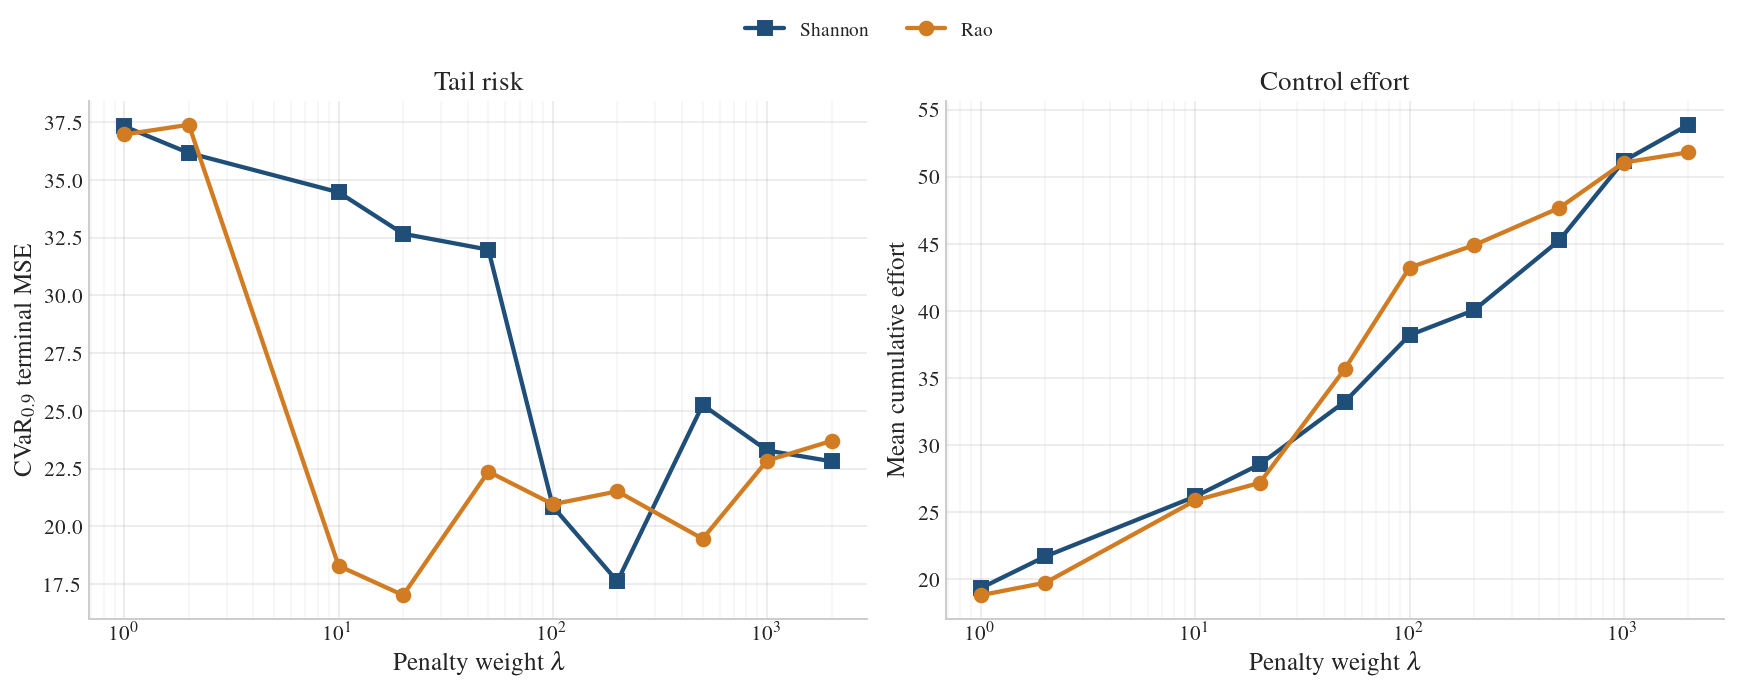

In [4]:
# Build long format for policy-by-policy plotting.
long = pd.concat([
    work[['lambda', 'sigma_r', 'sigma_phi', 'source_run_dir', 'source_summary_file',
          'cvar90_terminal_mse_shannon', 'mean_cumul_effort_shannon']]
        .rename(columns={
            'cvar90_terminal_mse_shannon': 'cvar90_terminal_mse',
            'mean_cumul_effort_shannon': 'mean_cumul_effort'
        })
        .assign(policy='Shannon'),
    work[['lambda', 'sigma_r', 'sigma_phi', 'source_run_dir', 'source_summary_file',
          'cvar90_terminal_mse_rao', 'mean_cumul_effort_rao']]
        .rename(columns={
            'cvar90_terminal_mse_rao': 'cvar90_terminal_mse',
            'mean_cumul_effort_rao': 'mean_cumul_effort'
        })
        .assign(policy='Rao')
], ignore_index=True)

trend = (
    long.groupby(['lambda', 'policy'], as_index=False)
    .agg(
        cvar90_terminal_mse=('cvar90_terminal_mse', 'median'),
        mean_cumul_effort=('mean_cumul_effort', 'median'),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True)
metric_specs = [
    ('cvar90_terminal_mse', r'$\mathrm{CVaR}_{0.9}$ terminal MSE', 'Tail risk'),
    ('mean_cumul_effort', 'Mean cumulative effort', 'Control effort'),
]

for ax, (metric, ylabel, title) in zip(axes, metric_specs):
    for policy in ['Shannon', 'Rao']:
        policy_df = trend[trend['policy'] == policy].sort_values('lambda')
        ax.plot(
            policy_df['lambda'],
            policy_df[metric],
            color=POLICY_COLORS[policy],
            marker=POLICY_MARKERS[policy],
            label=policy,
        )
    set_log_lambda_axis(ax)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    style_axes(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.03))
for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()

fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

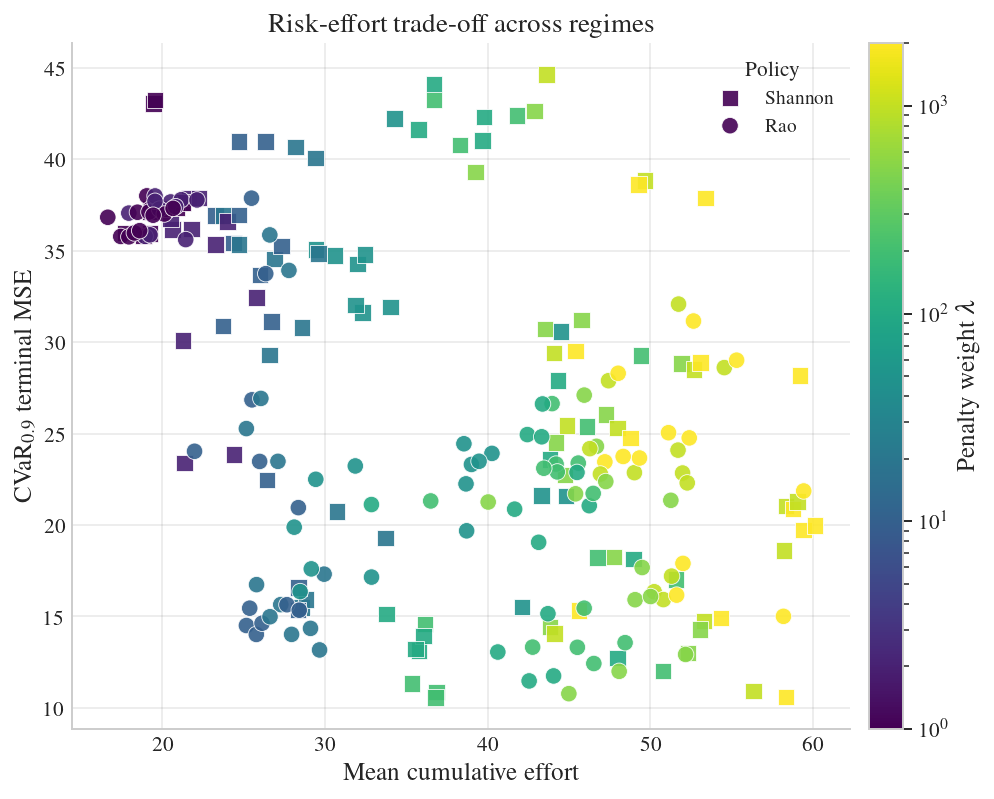

In [5]:
# Pareto-style view: each point is a (sigma_r, sigma_phi) regime at a given lambda.
fig, ax = plt.subplots(figsize=(7.4, 5.8))

positive_lambda = long.loc[long['lambda'] > 0, 'lambda']
lambda_norm = LogNorm(vmin=positive_lambda.min(), vmax=positive_lambda.max())

for policy in ['Shannon', 'Rao']:
    policy_df = long[long['policy'] == policy]
    ax.scatter(
        policy_df['mean_cumul_effort'],
        policy_df['cvar90_terminal_mse'],
        c=policy_df['lambda'],
        cmap='viridis',
        norm=lambda_norm,
        marker=POLICY_MARKERS[policy],
        s=72,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.45,
        label=policy,
    )

style_axes(ax)
ax.set_title('Risk-effort trade-off across regimes')
ax.set_xlabel('Mean cumulative effort')
ax.set_ylabel(r'$\mathrm{CVaR}_{0.9}$ terminal MSE')
ax.legend(title='Policy', frameon=False, loc='upper right')

cbar = fig.colorbar(ScalarMappable(norm=lambda_norm, cmap='viridis'), ax=ax, pad=0.02)
cbar.set_label(r'Penalty weight $\lambda$')

plt.tight_layout()
plt.show()

Lower scores are better. Top lambdas for both costs:


policy,lambda,Shannon,Rao,balanced_score_max,balanced_score_mean
5,100.0,-0.576140,-0.134791,-0.134791,-0.355465
6,200.0,-0.874973,0.085833,0.085833,-0.394570
0,1.0,0.149196,0.054619,0.149196,0.101908
1,2.0,0.186385,0.192824,0.192824,0.189605
3,20.0,0.274389,-2.050405,0.274389,-0.888008
2,10.0,0.325036,-1.982578,0.325036,-0.828771
4,50.0,0.573981,-0.574052,0.573981,-0.000035
7,500.0,0.644846,0.031277,0.644846,0.338061
8,1000.0,0.868146,0.795910,0.868146,0.832028
9,2000.0,1.029820,0.980677,1.029820,1.005249


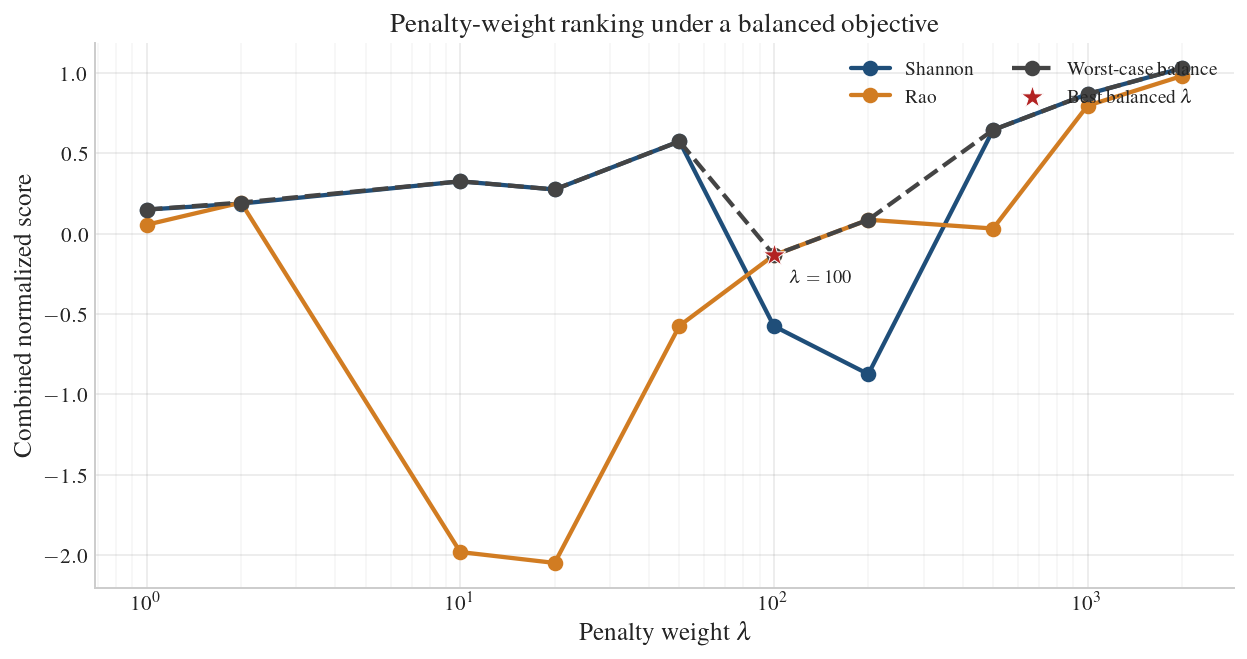

In [6]:
# Aggregate by lambda to score "good for both costs".
# We compute per-policy normalized score = z(CVaR) + z(Effort), then combine across both policies.
lam_pol = long.groupby(['lambda', 'policy'], as_index=False).agg(
    cvar90_med=('cvar90_terminal_mse', 'median'),
    effort_med=('mean_cumul_effort', 'median'),
)

for metric in ['cvar90_med', 'effort_med']:
    mu = lam_pol[metric].mean()
    sd = lam_pol[metric].std(ddof=0)
    lam_pol[f'z_{metric}'] = 0.0 if sd == 0 else (lam_pol[metric] - mu) / sd

lam_pol['policy_score'] = lam_pol['z_cvar90_med'] + lam_pol['z_effort_med']

lam_rank = (
    lam_pol
    .pivot(index='lambda', columns='policy', values='policy_score')
    .reset_index()
)

# Conservative balanced objective: keep both policies good.
lam_rank['balanced_score_max'] = lam_rank[['Shannon', 'Rao']].max(axis=1)
lam_rank['balanced_score_mean'] = lam_rank[['Shannon', 'Rao']].mean(axis=1)
lam_rank = lam_rank.sort_values('balanced_score_max')

display_cols = ['lambda', 'Shannon', 'Rao', 'balanced_score_max', 'balanced_score_mean']
print('Lower scores are better. Top lambdas for both costs:')
display(lam_rank[display_cols].head(10))

fig, ax = plt.subplots(figsize=(9.0, 4.8))
plot_rank = lam_rank.sort_values('lambda')
score_specs = [
    ('Shannon', 'Shannon', POLICY_COLORS['Shannon'], '-'),
    ('Rao', 'Rao', POLICY_COLORS['Rao'], '-'),
    ('balanced_score_max', 'Worst-case balance', '#444444', '--'),
]

for column, label, color, linestyle in score_specs:
    ax.plot(
        plot_rank['lambda'],
        plot_rank[column],
        marker='o',
        linestyle=linestyle,
        color=color,
        label=label,
    )

best_row = plot_rank.loc[plot_rank['balanced_score_max'].idxmin()]
ax.scatter(
    best_row['lambda'],
    best_row['balanced_score_max'],
    s=150,
    marker='*',
    color='#b22222',
    edgecolor='white',
    linewidth=0.5,
    zorder=5,
    label='Best balanced $\lambda$',
)
ax.annotate(
    fr'$\lambda={best_row["lambda"]:g}$',
    xy=(best_row['lambda'], best_row['balanced_score_max']),
    xytext=(8, -14),
    textcoords='offset points',
)

set_log_lambda_axis(ax)
ax.set_ylabel('Combined normalized score')
ax.set_title('Penalty-weight ranking under a balanced objective')
style_axes(ax)
ax.legend(frameon=False, ncol=2, loc='upper right')

plt.tight_layout()
plt.show()

## Best-Lambda-Per-Cost Comparison

If each cost function picks its own best `lambda` independently (by minimizing CVaR90), this section compares the resulting best-achievable policies across noise regimes.

In [7]:
# For each (sigma_r, sigma_phi), choose each cost's own best lambda by CVaR90.
best_sh = (
    df.loc[df.groupby(['sigma_r', 'sigma_phi'])['cvar90_terminal_mse_shannon'].idxmin()]
    [['sigma_r', 'sigma_phi', 'lambda', 'cvar90_terminal_mse_shannon', 'q95_terminal_mse_shannon', 'mean_cumul_effort_shannon']]
    .rename(columns={
        'lambda': 'lambda_best_sh',
        'cvar90_terminal_mse_shannon': 'cvar90_sh',
        'q95_terminal_mse_shannon': 'q95_sh',
        'mean_cumul_effort_shannon': 'effort_sh',
    })
)

best_ra = (
    df.loc[df.groupby(['sigma_r', 'sigma_phi'])['cvar90_terminal_mse_rao'].idxmin()]
    [['sigma_r', 'sigma_phi', 'lambda', 'cvar90_terminal_mse_rao', 'q95_terminal_mse_rao', 'mean_cumul_effort_rao']]
    .rename(columns={
        'lambda': 'lambda_best_ra',
        'cvar90_terminal_mse_rao': 'cvar90_ra',
        'q95_terminal_mse_rao': 'q95_ra',
        'mean_cumul_effort_rao': 'effort_ra',
    })
)

comparison = best_sh.merge(best_ra, on=['sigma_r', 'sigma_phi'])


def winner_with_tie(a, b, tol=0.5, label_a='Shannon', label_b='Rao'):
    diff = a - b
    if abs(diff) <= tol:
        return 'Tie'
    return label_b if diff > 0 else label_a


comparison['cvar90_winner'] = comparison.apply(
    lambda r: winner_with_tie(r['cvar90_sh'], r['cvar90_ra'], tol=0.5),
    axis=1,
)
comparison['effort_winner'] = comparison.apply(
    lambda r: winner_with_tie(r['effort_sh'], r['effort_ra'], tol=0.5),
    axis=1,
)

comparison = comparison.sort_values(['sigma_r', 'sigma_phi']).reset_index(drop=True)

comparison = comparison[[
    'sigma_r', 'sigma_phi',
    'lambda_best_sh', 'cvar90_sh', 'q95_sh', 'effort_sh',
    'lambda_best_ra', 'cvar90_ra', 'q95_ra', 'effort_ra',
    'cvar90_winner', 'effort_winner',
]]

print('Full best-lambda-per-cost comparison table:')
display(comparison)

# Summary counts requested.
cvar_counts = comparison['cvar90_winner'].value_counts().reindex(['Rao', 'Shannon', 'Tie'], fill_value=0)
effort_counts = comparison['effort_winner'].value_counts().reindex(['Rao', 'Shannon', 'Tie'], fill_value=0)
rao_pareto_count = ((comparison['cvar90_winner'] == 'Rao') & (comparison['effort_winner'] == 'Rao')).sum()

print(
    f"CVaR90 winners -> Rao: {cvar_counts['Rao']}, Shannon: {cvar_counts['Shannon']}, Tie: {cvar_counts['Tie']}"
)
print(
    f"Effort winners -> Rao: {effort_counts['Rao']}, Shannon: {effort_counts['Shannon']}, Tie: {effort_counts['Tie']}"
)
print(f'Rao Pareto-dominates (wins both CVaR90 and effort): {rao_pareto_count}')

Full best-lambda-per-cost comparison table:


,sigma_r,sigma_phi,lambda_best_sh,cvar90_sh,q95_sh,effort_sh,lambda_best_ra,cvar90_ra,q95_ra,effort_ra,cvar90_winner,effort_winner
0,0.50,0.3,1000.0,14.065942,9.727923,44.114677,100.0,13.057780,9.725765,40.628719,Rao,Rao
1,0.50,0.5,500.0,24.498770,28.125000,44.209417,10.0,14.507353,12.500000,25.166198,Rao,Rao
2,0.50,0.7,20.0,15.497390,10.853996,28.544156,10.0,14.018565,11.106673,25.776458,Rao,Rao
3,0.75,0.3,200.0,10.881755,6.258528,36.844958,100.0,11.477710,9.725765,42.555083,Shannon,Shannon
4,0.75,0.5,50.0,34.788865,28.125000,32.465990,500.0,10.780910,9.454719,44.997458,Rao,Shannon
5,0.75,0.7,1000.0,14.751101,12.950297,53.315219,20.0,14.350018,9.725765,29.108729,Tie,Rao
6,1.00,0.3,200.0,11.340622,9.008291,35.353510,100.0,15.150837,10.447485,43.711500,Shannon,Shannon
7,1.00,0.5,1000.0,28.499822,28.125000,52.682625,100.0,21.119673,28.125000,32.855927,Rao,Rao
8,1.00,0.7,200.0,12.032893,9.725765,50.785583,500.0,12.924494,9.876543,52.177937,Shannon,Shannon
9,1.25,0.3,200.0,10.562044,9.008291,36.789323,100.0,11.750909,9.008291,44.058542,Shannon,Shannon


CVaR90 winners -> Rao: 7, Shannon: 4, Tie: 1
Effort winners -> Rao: 6, Shannon: 6, Tie: 0
Rao Pareto-dominates (wins both CVaR90 and effort): 5


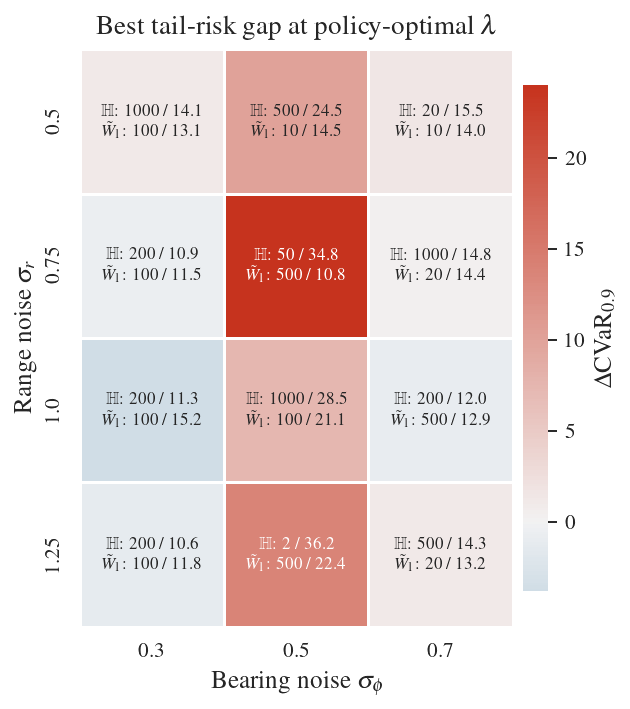

In [8]:
# Heatmap: best achievable CVaR90 gap when each cost uses its own optimal lambda.
# Positive delta means Rao is better (lower CVaR90).
heat_df = comparison.copy()
heat_df['delta_cvar90_sh_minus_ra'] = heat_df['cvar90_sh'] - heat_df['cvar90_ra']

pivot_delta = heat_df.pivot(index='sigma_r', columns='sigma_phi', values='delta_cvar90_sh_minus_ra')

# Annotation format is compact for single-column figures: lambda* / CVaR90.
annot = pivot_delta.copy().astype(object)
for sr in pivot_delta.index:
    for sp in pivot_delta.columns:
        row = heat_df[(heat_df['sigma_r'] == sr) & (heat_df['sigma_phi'] == sp)].iloc[0]
        annot.loc[sr, sp] = (
            fr'$\mathbb{{H}}$: {row["lambda_best_sh"]:g} / {row["cvar90_sh"]:.1f}' '\n'
            fr'$\tilde{{W}}_1$: {row["lambda_best_ra"]:g} / {row["cvar90_ra"]:.1f}'
        )

fig, ax = plt.subplots(figsize=(4.6, 5.3))
sns.heatmap(
    pivot_delta,
    annot=annot,
    fmt='',
    cmap=DELTA_CMAP,
    center=0,
    square=True,
    linewidths=0.6,
    linecolor='white',
    annot_kws={'fontsize': 8.8},
    cbar_kws={
        'shrink': 0.82,
        'pad': 0.02,
        'label': r'$\Delta \mathrm{CVaR}_{0.9}$',
    },
    ax=ax,
)
ax.set_title(r'Best tail-risk gap at policy-optimal $\lambda$', pad=8)
noise_axis_labels(ax)

plt.tight_layout()
plt.show()

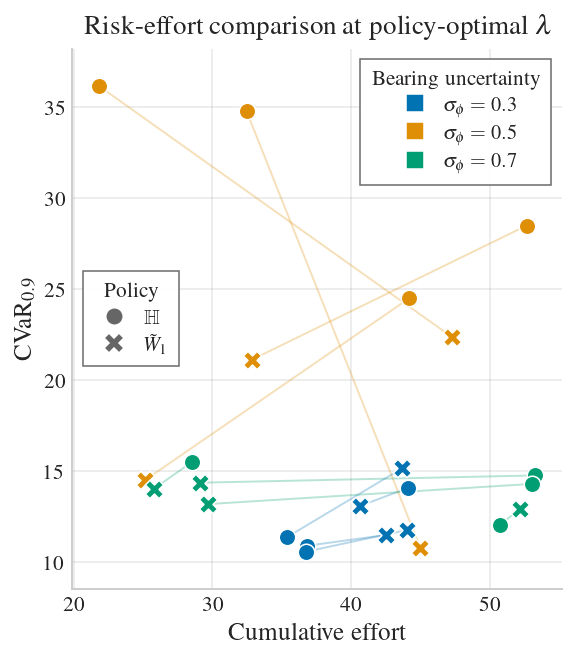

In [14]:
# Paired scatter: each regime contributes Shannon-vs-Rao pair at each cost's own best lambda.
# x = effort, y = CVaR90. Lower-left is better.
plot_df = comparison.copy()
phi_values = sorted(plot_df['sigma_phi'].unique())
phi_palette = dict(zip(phi_values, sns.color_palette('colorblind', n_colors=len(phi_values))))
policy_markers = {
    'Shannon': 'o',
    'Rao': 'X',
}

fig, ax = plt.subplots(figsize=(4.2, 4.8))

for _, r in plot_df.iterrows():
    color = phi_palette[r['sigma_phi']]

    # A thin connector shows the within-regime tradeoff while keeping emphasis on the markers.
    ax.plot(
        [r['effort_sh'], r['effort_ra']],
        [r['cvar90_sh'], r['cvar90_ra']],
        color=color,
        alpha=0.28,
        linewidth=1.0,
        zorder=1,
    )

    ax.scatter(
        r['effort_sh'],
        r['cvar90_sh'],
        marker=policy_markers['Shannon'],
        s=72,
        color=color,
        edgecolor='white',
        linewidth=0.8,
        zorder=3,
    )
    ax.scatter(
        r['effort_ra'],
        r['cvar90_ra'],
        marker=policy_markers['Rao'],
        s=88,
        color=color,
        edgecolor='white',
        linewidth=0.8,
        zorder=3,
    )

policy_handles = [
    Line2D([0], [0], marker=policy_markers['Shannon'], color='w', label=r'$\mathbb{H}$', markerfacecolor='#666666', markeredgecolor='white', markeredgewidth=0.8, markersize=9),
    Line2D([0], [0], marker=policy_markers['Rao'], color='w', label=r'$\tilde{W}_1$', markerfacecolor='#666666', markeredgecolor='white', markeredgewidth=0.8, markersize=10),
]
phi_handles = [
    Line2D([0], [0], marker='s', color='w', label=fr'$\sigma_{{\phi}}={sp:g}$', markerfacecolor=phi_palette[sp], markeredgecolor='white', markeredgewidth=0.8, markersize=9)
    for sp in phi_values
]

legend_style = {
    'frameon': True,
    'fancybox': False,
    'framealpha': 0.95,
    'facecolor': 'white',
    'edgecolor': '#666666',
    'borderpad': 0.55,
    'labelspacing': 0.35,
    'handletextpad': 0.45,
    'fontsize': 10.5,
    'title_fontsize': 11,
}
legend_policy = ax.legend(handles=policy_handles, title='Policy', loc='center left', **legend_style)
ax.add_artist(legend_policy)
ax.legend(handles=phi_handles, title=r'Bearing uncertainty', loc='upper right', **legend_style)

ax.set_title(r'Risk-effort comparison at policy-optimal $\lambda$', pad=8)
ax.set_xlabel('Cumulative effort')
ax.set_ylabel(r'$\mathrm{CVaR}_{0.9}$')
ax.margins(x=0.06, y=0.08)
style_axes(ax)

plt.tight_layout()
plt.show()

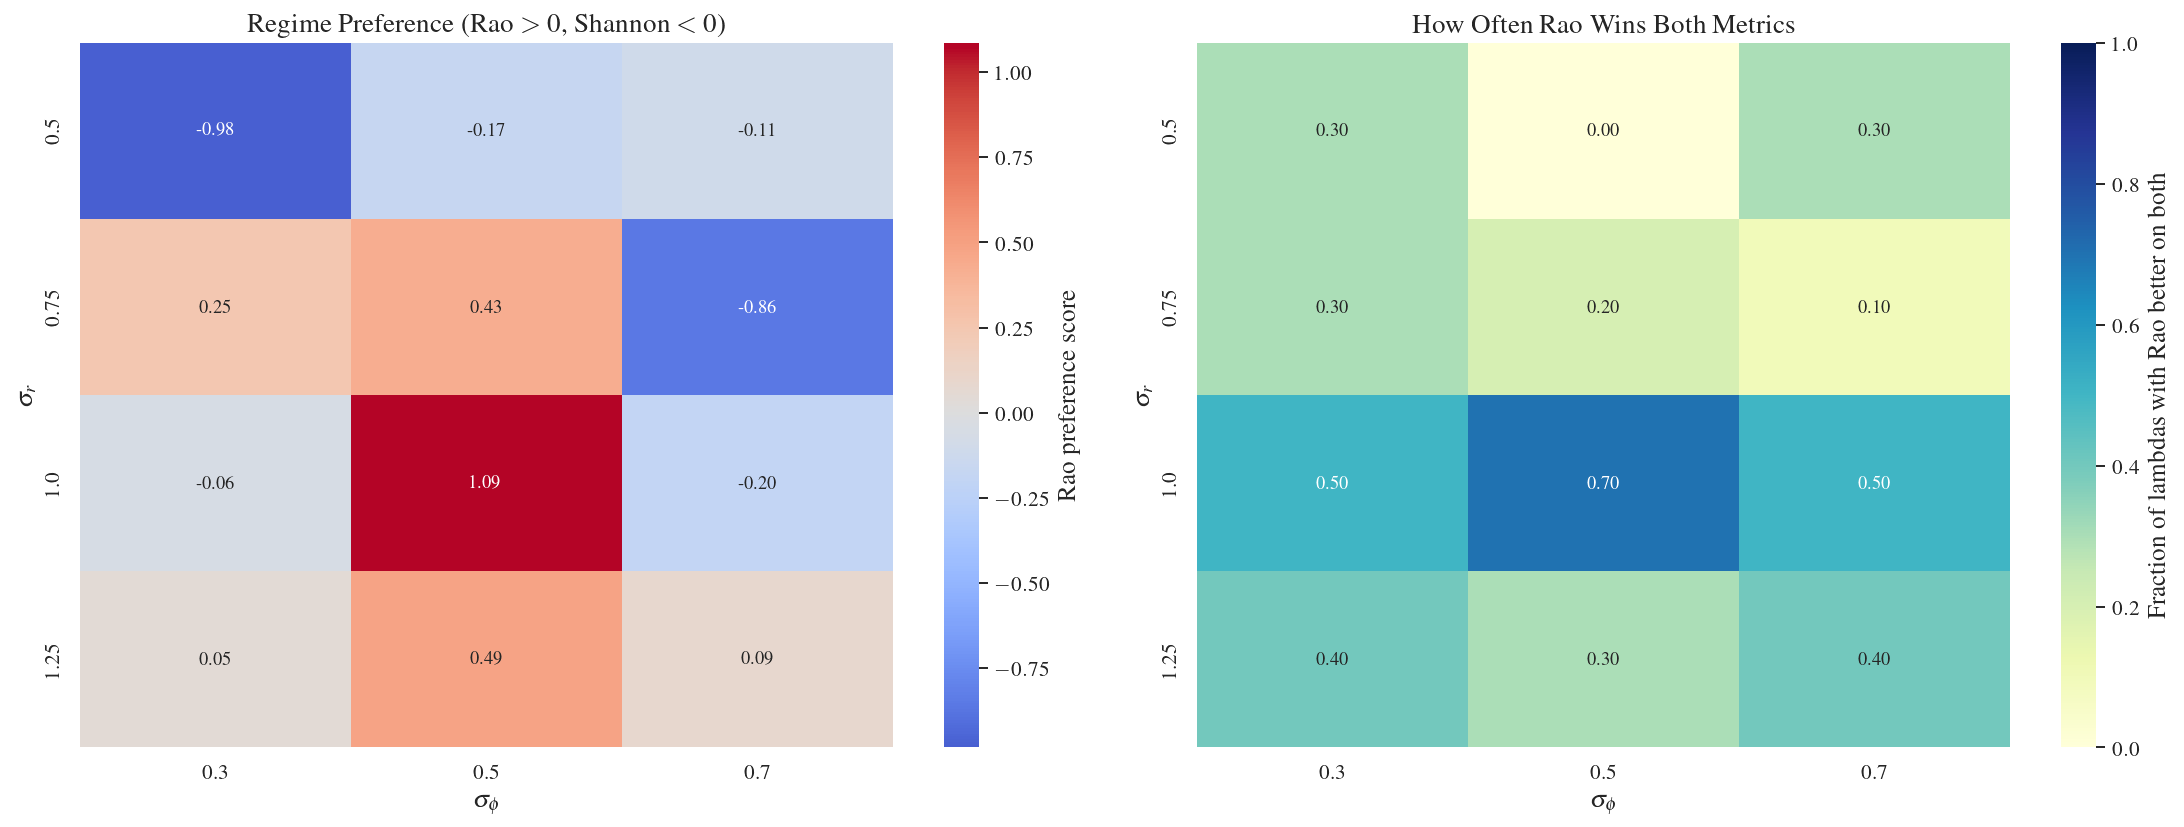

In [10]:
# Regime map: where is Rao preferred over Shannon?
# Positive score => Rao better on combined normalized deltas.
regime_pref = (
    work.groupby(['sigma_r', 'sigma_phi'], as_index=False)
    .agg(
        mean_preference_score_rao=('preference_score_rao', 'mean'),
        frac_rao_better_both=('rao_better_both', 'mean'),
        frac_shannon_better_both=('shannon_better_both', 'mean'),
        mean_rao_win_rate=('rao_win_rate_pooled', 'mean'),
    )
)

pivot_pref = regime_pref.pivot(index='sigma_r', columns='sigma_phi', values='mean_preference_score_rao')
pivot_frac = regime_pref.pivot(index='sigma_r', columns='sigma_phi', values='frac_rao_better_both')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    pivot_pref,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': 'Rao preference score'},
    ax=axes[0],
)
axes[0].set_title('Regime Preference (Rao $> 0$, Shannon $< 0$)')
axes[0].set_xlabel(r'$\sigma_{\phi}$')
axes[0].set_ylabel(r'$\sigma_{r}$')

sns.heatmap(
    pivot_frac,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Fraction of lambdas with Rao better on both'},
    ax=axes[1],
)
axes[1].set_title('How Often Rao Wins Both Metrics')
axes[1].set_xlabel(r'$\sigma_{\phi}$')
axes[1].set_ylabel(r'$\sigma_{r}$')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3200153/2851104370.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 0.96, 0.98))


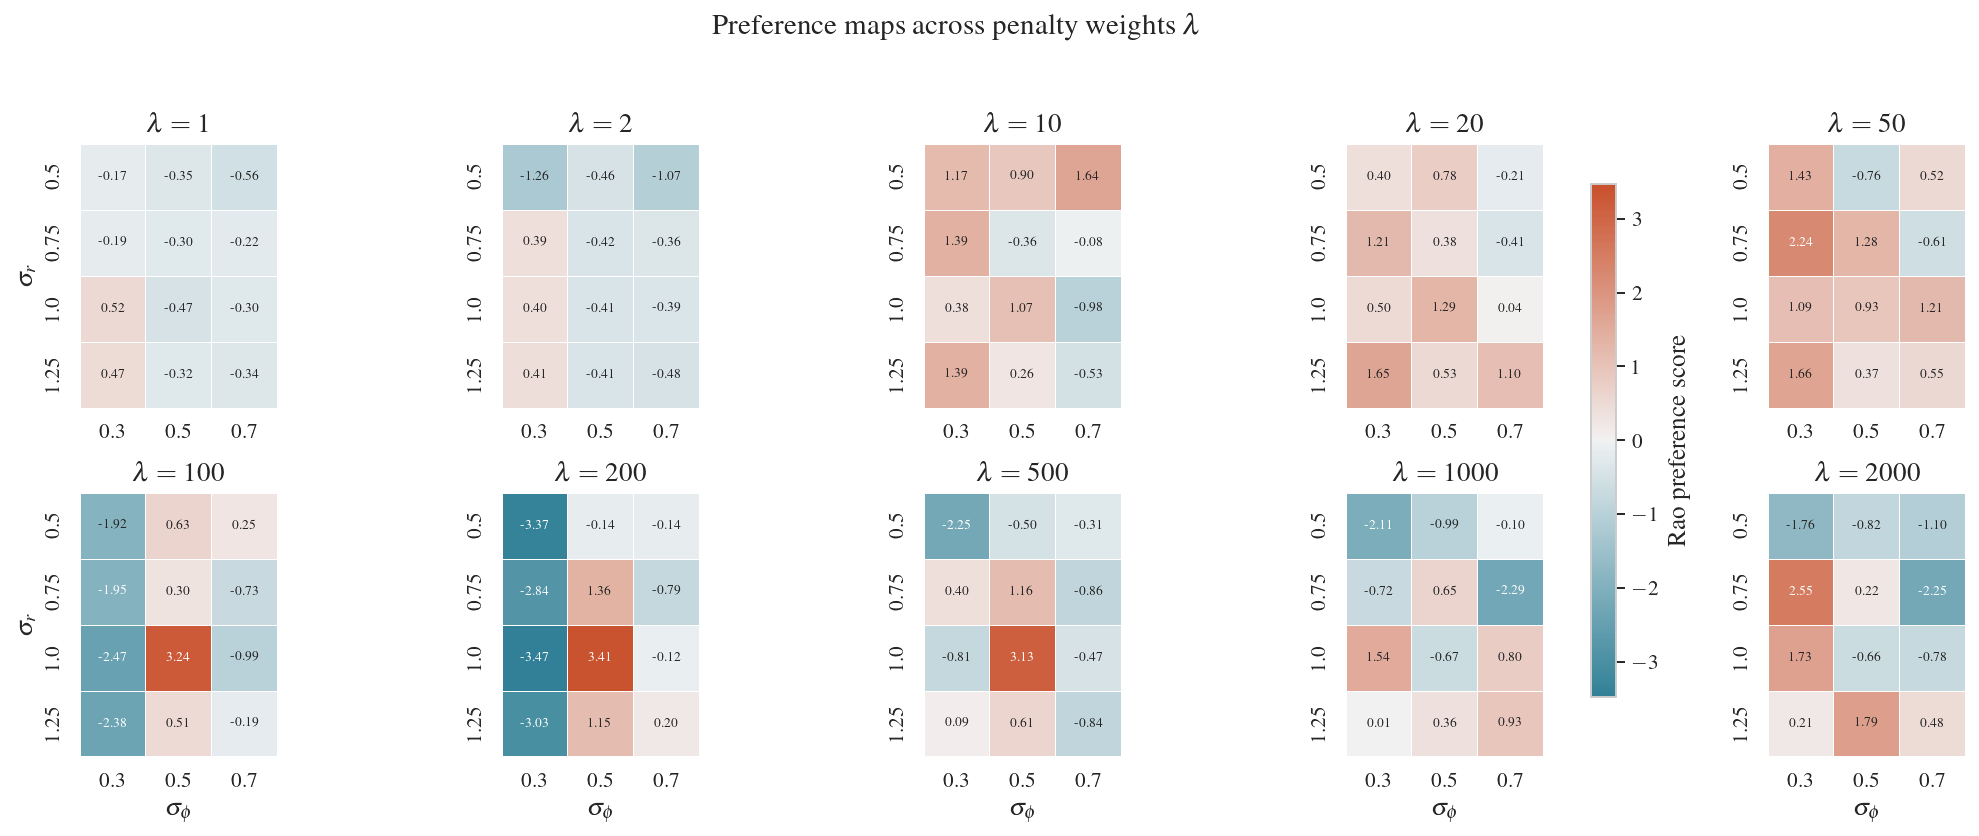

In [11]:
# Small-multiples: preference map at each lambda.
unique_lam = sorted(work['lambda'].unique())
max_panels = len(unique_lam)

ncols = 5
nrows = int(np.ceil(max_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.9 * nrows), squeeze=False)

vmax = np.nanmax(np.abs(work['preference_score_rao'].values))
vmin = -vmax
norm = Normalize(vmin=vmin, vmax=vmax)

for i, lam in enumerate(unique_lam):
    r, c = divmod(i, ncols)
    ax = axes[r][c]
    dfi = (
        work[work['lambda'] == lam]
        .groupby(['sigma_r', 'sigma_phi'], as_index=False)['preference_score_rao']
        .mean()
    )
    piv = dfi.pivot(index='sigma_r', columns='sigma_phi', values='preference_score_rao')
    sns.heatmap(
        piv,
        ax=ax,
        cmap=PREF_CMAP,
        center=0,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        annot=True,
        fmt='.2f',
        annot_kws={'fontsize': 7},
        square=True,
        linewidths=0.4,
        linecolor='white',
    )
    ax.set_title(fr'$\lambda = {lam:g}$', pad=6)
    ax.set_xlabel(r'$\sigma_{\phi}$' if r == nrows - 1 else '')
    ax.set_ylabel(r'$\sigma_{r}$' if c == 0 else '')

for j in range(max_panels, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r][c].axis('off')

cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=PREF_CMAP), ax=axes.ravel().tolist(), shrink=0.82, pad=0.02)
cbar.set_label('Rao preference score')
fig.suptitle(r'Preference maps across penalty weights $\lambda$', y=1.02)
fig.tight_layout(rect=(0, 0, 0.96, 0.98))
plt.show()

## Reading the outputs

- **Lambda trend plots**: look for lambda ranges where both Shannon and Rao curves are low for CVaR and effort.
- **Balanced ranking table**: lower `balanced_score_max` means the lambda performs well for both costs, not just one.
- **Regime heatmaps**:
  - Positive preference score: Rao tends to dominate (lower CVaR and/or effort).
  - Negative preference score: Shannon tends to dominate.
  - `frac_rao_better_both` close to 1 means Rao is consistently better on both metrics over lambda values.

If you want stricter criteria for "good policy," edit the scoring cell to use `q95_terminal_mse_*`, CVaR-only, or effort-only objectives.